<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/BigImgSingnal/uber_fare_prediction_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.12.0.dev20260312+cu130
Uninstalling torch-2.12.0.dev20260312+cu130:
  Successfully uninstalled torch-2.12.0.dev20260312+cu130
Found existing installation: torchvision 0.26.0.dev20260312+cu130
Uninstalling torchvision-0.26.0.dev20260312+cu130:
  Successfully uninstalled torchvision-0.26.0.dev20260312+cu130
Found existing installation: torchaudio 2.11.0.dev20260312+cu130
Uninstalling torchaudio-2.11.0.dev20260312+cu130:
  Successfully uninstalled torchaudio-2.11.0.dev20260312+cu130


In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 68.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 50.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 69.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 905.2/

In [1]:
from google.colab import drive
import torch
import pandas as pd
from torch import nn
import numpy as np
import torch.nn.functional as F


In [2]:
print(torch.version.cuda)
print(torch.cuda.is_available())

None
False


In [3]:
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [4]:
dataset_path = "/content/drive/MyDrive/Big Img Sig/Uber"

In [5]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
learning_rate = 0.0001
batch_size = 32
experiment_name = 'prova1'

In [6]:
device

'cpu'

In [7]:
dataset = pd.read_csv(f'{dataset_path}/val.csv', sep='\s+')
len(dataset)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_287/3901335374.py:1: SyntaxWarning: invalid escape sequence '\s'
  dataset = pd.read_csv(f'{dataset_path}/val.csv', sep='\s+')


19998

In [ ]:
dataset.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,Distance,month_1,month_2,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,-0.652389,-0.140406,0.136692,-0.139972,0.136307,-0.493901,-0.399941,-0.054162,-0.311289,3.313440,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
1,-0.642289,-0.139333,0.140029,-0.138858,0.140714,-0.493901,1.216060,-0.052260,3.212450,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
2,0.064650,-0.142788,0.134349,-0.141783,0.138648,-0.493901,0.138727,-0.045667,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,4.415280,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
3,-0.652389,-0.142140,0.136223,-0.140815,0.135641,-0.493901,-0.399941,-0.052054,-0.311289,3.313440,...,-0.226377,4.449900,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
4,0.569606,-0.142787,0.136007,-0.138969,0.137039,-0.493901,1.216060,-0.045906,3.212450,-0.301802,...,4.417420,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047


In [ ]:
dataset_columns = dataset.columns.tolist()
dataset_columns

['fare_amount',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count',
 'year',
 'Distance',
 'month_1',
 'month_2',
 'month_3',
 'month_4',
 'month_5',
 'month_6',
 'month_7',
 'month_8',
 'month_9',
 'month_10',
 'month_11',
 'month_12',
 'weekday_0',
 'weekday_1',
 'weekday_2',
 'weekday_3',
 'weekday_4',
 'weekday_5',
 'weekday_6',
 'hour_0',
 'hour_1',
 'hour_2',
 'hour_3',
 'hour_4',
 'hour_5',
 'hour_6',
 'hour_7',
 'hour_8',
 'hour_9',
 'hour_10',
 'hour_11',
 'hour_12',
 'hour_13',
 'hour_14',
 'hour_15',
 'hour_16',
 'hour_17',
 'hour_18',
 'hour_19',
 'hour_20',
 'hour_21',
 'hour_22',
 'hour_23']

In [8]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self, csv):
    self.df = pd.read_csv(csv, sep='\s+')
    self.input_cols = self.df.columns.drop('fare_amount').tolist()
    self.output_cols = ['fare_amount']

  def __len__(self):
    return len(self.df)
  def __getitem__(self, index):
    # read row, split in input and output and convert in tensors
    row= self.df.iloc[index]
    # split in input
    input_rows = row[self.input_cols]
    # split in output
    output_rows = row[self.output_cols]
    # convert input & output in tensors
    features = torch.tensor(input_rows.to_numpy(), dtype=torch.float32)
    ground_throuthg = torch.tensor(output_rows.to_numpy(), dtype=torch.float32)
    return features, ground_throuthg

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_287/3457717910.py:3: SyntaxWarning: invalid escape sequence '\s'
  self.df = pd.read_csv(csv, sep='\s+')


In [10]:
# create train and validation datasets
train_ds = Dataset(f'{dataset_path}/train.csv')
val_ds =  Dataset(f'{dataset_path}/val.csv')

### Explore the dataset

In [ ]:
val_ds.df.shape

(100, 51)

In [ ]:
val_ds.__getitem__(0)

(tensor([-0.1404,  0.1367, -0.1400,  0.1363, -0.4939, -0.3999, -0.0542, -0.3113,
          3.3134, -0.3218, -0.3203, -0.3227, -0.3124, -0.2857, -0.2767, -0.2875,
         -0.2970, -0.2879, -0.2900, -0.3801, -0.4045, -0.4121, -0.4203, -0.4273,
          2.3690, -0.3903, -0.2020, -0.1745,  6.6502, -0.1286, -0.1094, -0.0996,
         -0.1454, -0.1937, -0.2180, -0.2213, -0.2164, -0.2223, -0.2285, -0.2297,
         -0.2264, -0.2247, -0.2082, -0.2265, -0.2535, -0.2594, -0.2499, -0.2464,
         -0.2415, -0.2270]),
 tensor([-0.6524]))

In [ ]:
val_ds.df[:2]

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,Distance,month_1,month_2,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,-0.652389,-0.140406,0.136692,-0.139972,0.136307,-0.493901,-0.399941,-0.054162,-0.311289,3.313440,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
1,-0.642289,-0.139333,0.140029,-0.138858,0.140714,-0.493901,1.216060,-0.052260,3.212450,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047


In [ ]:
val_ds.df.iloc[0]

,0
fare_amount,-0.652389
pickup_longitude,-0.140406
pickup_latitude,0.136692
dropoff_longitude,-0.139972
dropoff_latitude,0.136307
passenger_count,-0.493901
year,-0.399941
Distance,-0.054162
month_1,-0.311289
month_2,3.313440


In [ ]:
xx, yy = val_ds.__getitem__(0)

In [ ]:
yy

tensor([-0.6524])

In [ ]:
xx

tensor([-0.1404,  0.1367, -0.1400,  0.1363, -0.4939, -0.3999, -0.0542, -0.3113,
         3.3134, -0.3218, -0.3203, -0.3227, -0.3124, -0.2857, -0.2767, -0.2875,
        -0.2970, -0.2879, -0.2900, -0.3801, -0.4045, -0.4121, -0.4203, -0.4273,
         2.3690, -0.3903, -0.2020, -0.1745,  6.6502, -0.1286, -0.1094, -0.0996,
        -0.1454, -0.1937, -0.2180, -0.2213, -0.2164, -0.2223, -0.2285, -0.2297,
        -0.2264, -0.2247, -0.2082, -0.2265, -0.2535, -0.2594, -0.2499, -0.2464,
        -0.2415, -0.2270])

In [ ]:
val_ds.output_cols

['fare_amount']

In [ ]:
val_ds.input_cols[:5]

['pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count']

In [ ]:
val_ds.__len__()

100

In [ ]:
val_ds.df.tail()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,Distance,month_1,month_2,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
95,-0.652389,-0.143155,0.135944,-0.143447,0.133817,0.949105,-0.399941,-0.050632,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
96,-0.410009,-0.143097,0.131691,-0.143924,0.128847,-0.493901,-1.477280,-0.048907,-0.311289,-0.301802,...,-0.226377,-0.224724,4.802090,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
97,-0.329216,-0.143215,0.134966,-0.141375,0.131614,-0.493901,-1.477280,-0.047926,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
98,-0.541298,-0.138957,0.140452,-0.138348,0.142124,-0.493901,1.216060,-0.050477,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047
99,-0.652389,-0.141978,0.134421,-0.140723,0.133571,-0.493901,-0.399941,-0.052078,-0.311289,-0.301802,...,-0.226377,-0.224724,-0.208243,-0.226486,-0.25346,-0.259352,-0.249899,-0.246391,-0.241524,-0.227047


### Prepare the dataset

In [ ]:
train_ds.df.shape, val_ds.df.shape

((159990, 51), (19998, 51))

In [ ]:
train_ds.__getitem__(0)

(tensor([-0.1422,  0.1359, -0.1393,  0.1383, -0.4939,  0.1387, -0.0466, -0.3113,
         -0.3018, -0.3218, -0.3203, -0.3227, -0.3124, -0.2857,  3.6144, -0.2875,
         -0.2970, -0.2879, -0.2900, -0.3801, -0.4045, -0.4121,  2.3794, -0.4273,
         -0.4221, -0.3903, -0.2020, -0.1745, -0.1504, -0.1286, -0.1094, -0.0996,
         -0.1454, -0.1937, -0.2180, -0.2213, -0.2164, -0.2223, -0.2285, -0.2297,
         -0.2264, -0.2247, -0.2082, -0.2265,  3.9454, -0.2594, -0.2499, -0.2464,
         -0.2415, -0.2270]),
 tensor([-0.2888]))

In [11]:
# prepare the datast loader with torch data loader for training and testing
train_data_loader = torch.utils.data.DataLoader(dataset=train_ds,
                                                batch_size=batch_size,
                                                shuffle=True,
                                                drop_last=True,
                                                num_workers=2)
test_data_loader = torch.utils.data.DataLoader(dataset=val_ds,
                                                batch_size=batch_size,
                                                shuffle=True,
                                                drop_last=True,
                                                num_workers=2)

In [12]:
len(train_data_loader.dataset), len(test_data_loader.dataset), f"Number of Batches: {len(train_data_loader)}"

(159990, 19998, 'Number of Batches: 4999')

#### Exploare the inputs and ground throught data

In [ ]:
for batch, (X, y) in enumerate(train_data_loader):
  print(f'batch: {batch}\n X: {X[:1][0][:4]}\n y: {y[:1]}\n Feature shape: {X.shape} \n Atribute shape: {y.shape}')
  if batch>=5: break

batch: 0
 X: tensor([-0.2094,  0.8342, -0.2092,  0.8352])
 y: tensor([[-0.4908]])
 Feature shape: torch.Size([32, 50]) 
 Atribute shape: torch.Size([32, 1])
batch: 1
 X: tensor([-0.1424,  0.1334, -0.1430,  0.1324])
 y: tensor([[-0.4908]])
 Feature shape: torch.Size([32, 50]) 
 Atribute shape: torch.Size([32, 1])
batch: 2
 X: tensor([-0.1443,  0.1285, -0.1421,  0.1349])
 y: tensor([[-0.0868]])
 Feature shape: torch.Size([32, 50]) 
 Atribute shape: torch.Size([32, 1])
batch: 3
 X: tensor([-0.1415,  0.1332, -0.1307,  0.1393])
 y: tensor([[1.9734]])
 Feature shape: torch.Size([32, 50]) 
 Atribute shape: torch.Size([32, 1])
batch: 4
 X: tensor([-0.1424,  0.1330, -0.1412,  0.1377])
 y: tensor([[0.0344]])
 Feature shape: torch.Size([32, 50]) 
 Atribute shape: torch.Size([32, 1])
batch: 5
 X: tensor([-0.1439,  0.1343, -0.1440,  0.1285])
 y: tensor([[0.0646]])
 Feature shape: torch.Size([32, 50]) 
 Atribute shape: torch.Size([32, 1])


In [ ]:
X.to('cuda')

### Creating Models

In [13]:
np.shape(train_ds.input_cols)

(50,)

In [18]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    # Super will automatically call the parrent of the class from nn.Module and execute them by init method
    super(NeuralNetwork, self).__init__()
    # initialize the layer
    self.layer1 = nn.Linear(in_features=50, out_features=128)
    self.layer2 = nn.ReLU()
    self.layer3 = nn.Linear(in_features=128, out_features=64)
    self.layer4 = nn.ReLU()
    self.layer5 = nn.Linear(in_features=64, out_features=32)
    self.layer6 = nn.ReLU()
    # output layer
    self.layer7 = nn.Linear(in_features=32, out_features=1)

  # how data will pass through network
  def forward(self, x):
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.layer5(x)
    x = self.layer6(x)
    x = self.layer7(x)
    return x

# Move the network in GPU
model = NeuralNetwork().to(device)
model

NeuralNetwork(
  (layer1): Linear(in_features=50, out_features=128, bias=True)
  (layer2): ReLU()
  (layer3): Linear(in_features=128, out_features=64, bias=True)
  (layer4): ReLU()
  (layer5): Linear(in_features=64, out_features=32, bias=True)
  (layer6): ReLU()
  (layer7): Linear(in_features=32, out_features=1, bias=True)
)

#### Explore the model

In [ ]:
# Test the Network
md = NeuralNetwork()
md

NeuralNetwork(
  (layer1): Linear(in_features=50, out_features=128, bias=True)
  (layer2): ReLU()
  (layer3): Linear(in_features=128, out_features=64, bias=True)
  (layer4): ReLU()
  (layer5): Linear(in_features=64, out_features=32, bias=True)
  (layer6): ReLU()
  (layer7): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
# Define a 10 random input element
inp = torch.rand(10, 50)
inp.shape

torch.Size([10, 50])

In [ ]:
# forward to the network
outp = md(inp)
outp, outp.shape, f"Argmax: { outp.argmax(1)}"

(tensor([[0.2507],
         [0.2578],
         [0.2530],
         [0.2598],
         [0.2535],
         [0.2536],
         [0.2588],
         [0.2605],
         [0.2670],
         [0.2429]], grad_fn=<AddmmBackward0>),
 torch.Size([10, 1]),
 'Argmax: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])')

In [ ]:
# let's move the network in GPU
md.to(device=device)
# define a random batch
inp = torch.rand(10, 50)
inp = inp.to(device)
# forward to network
outp = md(inp)
md, outp, outp.shape

(NeuralNetwork(
   (layer1): Linear(in_features=50, out_features=128, bias=True)
   (layer2): ReLU()
   (layer3): Linear(in_features=128, out_features=64, bias=True)
   (layer4): ReLU()
   (layer5): Linear(in_features=64, out_features=32, bias=True)
   (layer6): ReLU()
   (layer7): Linear(in_features=32, out_features=1, bias=True)
 ),
 tensor([[0.2497],
         [0.2670],
         [0.2444],
         [0.2634],
         [0.2433],
         [0.2498],
         [0.2616],
         [0.2526],
         [0.2543],
         [0.2475]], grad_fn=<AddmmBackward0>),
 torch.Size([10, 1]))

### Optimizing the Model Parameters
To train a model, we need a loss function and an optimizer.



In [16]:
loss_fun = nn.functional.l1_loss
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

### Define the Train model preccess

In [19]:
def train_model(dataloader, model, loss_fun, optimizer, verbose=0):
  size = len(dataloader.dataset)
  model.train() # <-- Set model to training mode
  total_loss =0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    # Compute the prediction error
    pred = model(X)
    loss = loss_fun(input=pred, target=y)

    # Backpropagation
    loss.backward() # <-- compute the gradient
    # update weights
    optimizer.step() # <-- optimize NN by 1 batch
    optimizer.zero_grad() # <-- resets the gradients to zero before the next update
    total_loss += loss.item()

    if verbose>0 & batch % 100 == 0:
      loss, current = loss.item(), (batch+1)*len(X)
      print(f'loss: {loss:>7f}  [{current:>5d}/{size:>5d}]')
  train_loss = total_loss / len(dataloader)
  return train_loss

**We also check the model’s performance against the test dataset to ensure it is learning.**



In [20]:
def validate_regression(model, dataloader):
    """
    Evaluate a regression model on a dataloader.
    Returns:
        avg_loss: average L1 loss
        r2_score: R² metric
        mape: mean absolute percentage in %
          how far off your predictions are from the true values
           lower percentages indicating better performance
        ```
        MAPE=(1/n)∑(∣yi​−y^​i​∣​)/​∣yi​∣

        ```
    """
    model.eval()  # evaluation mode
    total_loss = 0
    total_error = 0   # for R²
    total_var = 0     # for R²
    total_mape = 0
    total_samples = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            # L1 loss
            batch_loss = F.l1_loss(pred, y, reduction='sum')
            total_loss += batch_loss.item()

            # R² score calculation
            y_mean = y.mean()
            total_var += ((y - y_mean) ** 2).sum().item()
            total_error += ((y - pred) ** 2).sum().item()

            # MAPE calculation
            total_mape += (torch.abs((y - pred) / (y + 1e-8))).sum().item()

            total_samples += y.numel()

    # Average metrics
    avg_loss = total_loss / total_samples # <-- Avg loss → standard MSE/MAE for regression
    r2 = 1 - (total_error / total_var) # <-- 1 means perfect prediction, 0 means model predicts just the mean, negative → model is worse than mean
    mape = (total_mape / total_samples) * 100  # percentage

    model.train()  # back to training mode
    return avg_loss, r2, mape

**Train the model**

In [21]:
epoch = 10
train_losses = []
val_losses = []
for t in range(epoch):
  print(f'Epoch {t+1} \n ---------------------------------------------------------------------')
  train_loss = train_model(dataloader=train_data_loader, model=model, loss_fun=loss_fun, optimizer=optimizer)
  train_losses.append(train_loss)
  avg_loss, r2_score, mape = validate_regression(dataloader=test_data_loader, model=model )
  val_losses.append(avg_loss)
  print(f"Validation: \n L1 Loss: {avg_loss:.4f}\t R²: {r2_score:.4f}\t MAPE: {mape:.2f}% \n")

# save model
torch.save(model.state_dict(), 'mode.path')
print("Done!")


Epoch 1 
 ---------------------------------------------------------------------
Validation: 
 L1 Loss: 0.6902	 R²: -0.0603	 MAPE: 178.91% 

Epoch 2 
 ---------------------------------------------------------------------
Validation: 
 L1 Loss: 0.6900	 R²: -0.0612	 MAPE: 178.83% 

Epoch 3 
 ---------------------------------------------------------------------
Validation: 
 L1 Loss: 0.6900	 R²: -0.0636	 MAPE: 179.00% 

Epoch 4 
 ---------------------------------------------------------------------
Validation: 
 L1 Loss: 0.6899	 R²: -0.0634	 MAPE: 179.14% 

Epoch 5 
 ---------------------------------------------------------------------
Validation: 
 L1 Loss: 0.6900	 R²: -0.0580	 MAPE: 179.07% 

Epoch 6 
 ---------------------------------------------------------------------
Validation: 
 L1 Loss: 0.6901	 R²: -0.0586	 MAPE: 179.10% 

Epoch 7 
 ---------------------------------------------------------------------
Validation: 
 L1 Loss: 0.6899	 R²: -0.0618	 MAPE: 178.90% 

Epoch 8 
 ----------

**Evaluate the model loss and accuracy history**

* train_loss ↓ and val_loss ↓ → good learning

* train_loss ↓ but val_loss ↑ → overfitting

* both high and flat → underfitting

<Axes: >

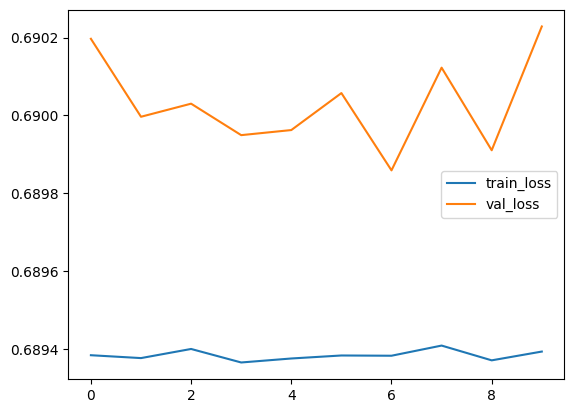

In [22]:
history= pd.DataFrame({'train_loss': train_losses, 'val_loss': val_losses})
history.plot()

**Predtion**

In [23]:
# Load the test dataset
test_data =  Dataset(f'{dataset_path}/test.csv')

In [24]:
# Create a test dataloader
test_dataloaer = torch.utils.data.DataLoader(dataset=test_data,
                                             batch_size=batch_size,
                                             shuffle=False,
                                             drop_last=False,
                                             num_workers=2)

In [25]:
# Load the model
new_model = NeuralNetwork().to(device)
new_model.load_state_dict(state_dict=torch.load('/content/drive/MyDrive/Big Img Sig/Uber/mode.path', weights_only=True))

<All keys matched successfully>

In [26]:
# Evaluate loaded modle on test dataset
avg_loss, r2_score, mape = validate_regression(dataloader=test_dataloaer, model=new_model )
print(f"Validation: \n L1 Loss: {avg_loss:.4f}\t R²: {r2_score:.4f}\t MAPE: {mape:.2f}% \n")

Validation: 
 L1 Loss: 0.6953	 R²: -0.0564	 MAPE: 179.42% 

